# Phase 5: Machine Learning Forecast

## Objective

The objective of this notebook is to build, train and compare multiple machine learning models for retail demand forecasting.

The models will be evaluated using MAE, RMSE and R² Score. The best-performing model will be selected and saved for the Risk Scoring and Dashboard phases.

---

## Workflow

1. Load Forecast Dataset
2. Validate Dataset
3. Data Preparation
4. Feature Selection
5. Time-Based Train-Test Split
6. Random Forest
7. XGBoost
8. LightGBM
9. Prophet
10. ARIMA/SARIMA
11. Model Comparison
12. Best Model Selection
13. Save Best Model

In [1]:
import pandas as pd
import numpy as np

import joblib

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Forecast Dataset

In [2]:
forecast = pd.read_csv(
    "../data/processed/merged_dataset.csv"
)

print("Dataset Loaded Successfully")

forecast.head()

Dataset Loaded Successfully


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,...,day_name,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30,stock_gap,stock_status
0,2022-09-18,RCPT01376550,ST06,SKU01719,CUST04115,1,460.32,460.32,Online,0.0,...,Sunday,6,1,1.0,2.0,1.0,2.428571,1.900000,0.0,Normal
1,2023-05-26,RCPT02695129,ST05,SKU01551,CUST03306,1,179.55,179.55,In-Store,0.0,...,Friday,4,0,1.0,2.0,3.0,1.142857,1.366667,0.0,Normal
2,2025-08-25,RCPT04093705,ST30,SKU00169,CUST09964,5,95.37,476.85,Online,0.0,...,Monday,0,0,1.0,1.0,1.0,2.571429,2.166667,0.0,Normal
3,2025-01-10,RCPT00287939,ST22,SKU00453,CUST04050,1,382.55,382.55,In-Store,0.0,...,Friday,4,0,1.0,1.0,1.0,2.142857,1.733333,0.0,Normal
4,2025-06-22,RCPT03460988,ST21,SKU00845,CUST00967,2,670.83,1341.66,In-Store,0.0,...,Sunday,6,1,2.0,1.0,3.0,1.428571,1.566667,0.0,Normal


# Dataset Overview

In [3]:
forecast.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               100000 non-null  str    
 1   receipt_id         100000 non-null  str    
 2   store_id           100000 non-null  str    
 3   sku_id             100000 non-null  str    
 4   customer_id        100000 non-null  str    
 5   quantity           100000 non-null  int64  
 6   unit_price         100000 non-null  float64
 7   total_value        100000 non-null  float64
 8   channel            100000 non-null  str    
 9   discount_pct       100000 non-null  float64
 10  promo_id           100000 non-null  str    
 11  sku_name           100000 non-null  str    
 12  category           100000 non-null  str    
 13  subcategory        100000 non-null  str    
 14  cost_price         100000 non-null  float64
 15  brand              100000 non-null  str    
 16  stock_on_hand 

# Dataset Validation

In [4]:
print("Dataset Shape :", forecast.shape)

print("\nDuplicate Rows :", forecast.duplicated().sum())

print("\nMissing Values")

display(forecast.isnull().sum())

Dataset Shape : (100000, 36)



Duplicate Rows : 0

Missing Values


date                     0
receipt_id               0
store_id                 0
sku_id                   0
customer_id              0
quantity                 0
unit_price               0
total_value              0
channel                  0
discount_pct             0
promo_id                 0
sku_name                 0
category                 0
subcategory              0
cost_price               0
brand                    0
stock_on_hand            0
reorder_point            0
safety_stock             0
last_restock_date    79496
year                     0
month                    0
month_name               0
quarter                  0
week                     0
day                      0
day_name                 0
day_of_week              0
is_weekend               0
lag_1                    0
lag_7                    0
lag_30                   0
rolling_7                0
rolling_30               0
stock_gap                0
stock_status             0
dtype: int64

# Convert Date Column

In [5]:
forecast["date"] = pd.to_datetime(forecast["date"])

forecast = forecast.sort_values("date")

# Encode Categorical Variables

In [ ]:
encoder = LabelEncoder()

categorical_columns = [

    "store_id",

    "sku_id",

    "category",

    "channel"

]

for col in categorical_columns:

    forecast[col] = encoder.fit_transform(
        forecast[col].astype(str)
    )

print("Encoding Completed Successfully")

Encoding Completed Successfully


# Feature Selection

In [7]:
TARGET = "quantity"

FEATURES = [

    "store_id",

    "sku_id",

    "category",

    "channel",

    "unit_price",

    "discount_pct",

    "stock_on_hand",

    "reorder_point",

    "safety_stock",

    "year",

    "month",

    "week",

    "day",

    "day_of_week",

    "is_weekend",

    "lag_1",

    "lag_7",

    "lag_30",

    "rolling_7",

    "rolling_30",

    "stock_gap"

]

# Time-Based Train-Test Split

In [8]:
split = int(len(forecast) * 0.80)

train = forecast.iloc[:split]

test = forecast.iloc[split:]

X_train = train[FEATURES]

y_train = train[TARGET]

X_test = test[FEATURES]

y_test = test[TARGET]

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (80000, 21)
Testing Shape : (20000, 21)


# Reduce Training Size

A representative sample is used for faster model training while preserving the characteristics of the full dataset.

In [10]:
# Use complete training data
X_train = train[FEATURES]
y_train = train[TARGET]

print("Training Shape :", X_train.shape)

Training Shape : (80000, 21)


# Model 1: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It serves as a strong benchmark for demand forecasting.

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


# Evaluate Random Forest Model

In [12]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", round(rf_mae,2))

print("RMSE :", round(rf_rmse,2))

print("R² Score :", round(rf_r2,4))

MAE : 0.81
RMSE : 1.01
R² Score : 0.134


# Model 2: XGBoost Regressor

XGBoost is a gradient boosting algorithm that is highly effective for structured retail datasets. It captures complex relationships between features and generally provides better forecasting performance than traditional models.

In [13]:
xgb_model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=8,

    random_state=42,

    objective="reg:squarederror"

)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


# Evaluate XGBoost Model

In [14]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE :", round(xgb_mae,2))

print("RMSE :", round(xgb_rmse,2))

print("R² Score :", round(xgb_r2,4))

MAE : 0.79
RMSE : 0.99
R² Score : 0.1578


# Model 3: LightGBM Regressor

LightGBM is an optimized gradient boosting framework designed for large datasets. It offers faster training speed and lower memory usage while maintaining high prediction accuracy.

In [15]:
lgbm_model = LGBMRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=8,

    random_state=42

)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

print("LightGBM Model Trained Successfully")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1455
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 21
[LightGBM] [Info] Start training from score 1.884700
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Model Trained Successfully


# Evaluate LightGBM Model

In [16]:
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)

lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

lgbm_r2 = r2_score(y_test, lgbm_pred)

print("MAE :", round(lgbm_mae,2))

print("RMSE :", round(lgbm_rmse,2))

print("R² Score :", round(lgbm_r2,4))

MAE : 0.79
RMSE : 0.99
R² Score : 0.1705


# Model 4: Prophet Forecasting

Prophet is a forecasting model developed by Meta for univariate time series forecasting. It automatically models trend, seasonality, and holiday effects.

In [17]:
from prophet import Prophet

print("Prophet Imported Successfully")

Prophet Imported Successfully


# Prepare Daily Sales Dataset for Prophet

In [18]:
daily_sales = (
    forecast
    .groupby("date")["quantity"]
    .sum()
    .reset_index()
)

daily_sales.columns = ["ds", "y"]

daily_sales.head()

,ds,y
0,2022-01-01,92
1,2022-01-02,95
2,2022-01-03,116
3,2022-01-04,76
4,2022-01-05,86


# Train Prophet Model

In [19]:
prophet_model = Prophet()

prophet_model.fit(daily_sales)

future = prophet_model.make_future_dataframe(periods=30)

forecast_prophet = prophet_model.predict(future)

forecast_prophet.head()

22:56:22 - cmdstanpy - INFO - Chain [1] start processing
22:56:23 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-01-01,116.638851,102.247751,152.267746,116.638851,116.638851,10.887257,10.887257,10.887257,2.111055,2.111055,2.111055,8.776202,8.776202,8.776202,0.0,0.0,0.0,127.526108
1,2022-01-02,116.654594,97.907654,147.425317,116.654594,116.654594,5.338695,5.338695,5.338695,0.328265,0.328265,0.328265,5.010430,5.010430,5.010430,0.0,0.0,0.0,121.993289
2,2022-01-03,116.670338,94.689081,142.812664,116.670338,116.670338,2.892459,2.892459,2.892459,1.544806,1.544806,1.544806,1.347653,1.347653,1.347653,0.0,0.0,0.0,119.562797
3,2022-01-04,116.686081,87.909440,136.999922,116.686081,116.686081,-4.903110,-4.903110,-4.903110,-2.735042,-2.735042,-2.735042,-2.168067,-2.168067,-2.168067,0.0,0.0,0.0,111.782972
4,2022-01-05,116.701825,85.612001,134.791968,116.701825,116.701825,-6.555678,-6.555678,-6.555678,-1.059441,-1.059441,-1.059441,-5.496237,-5.496237,-5.496237,0.0,0.0,0.0,110.146147


# Prophet Forecast Visualization

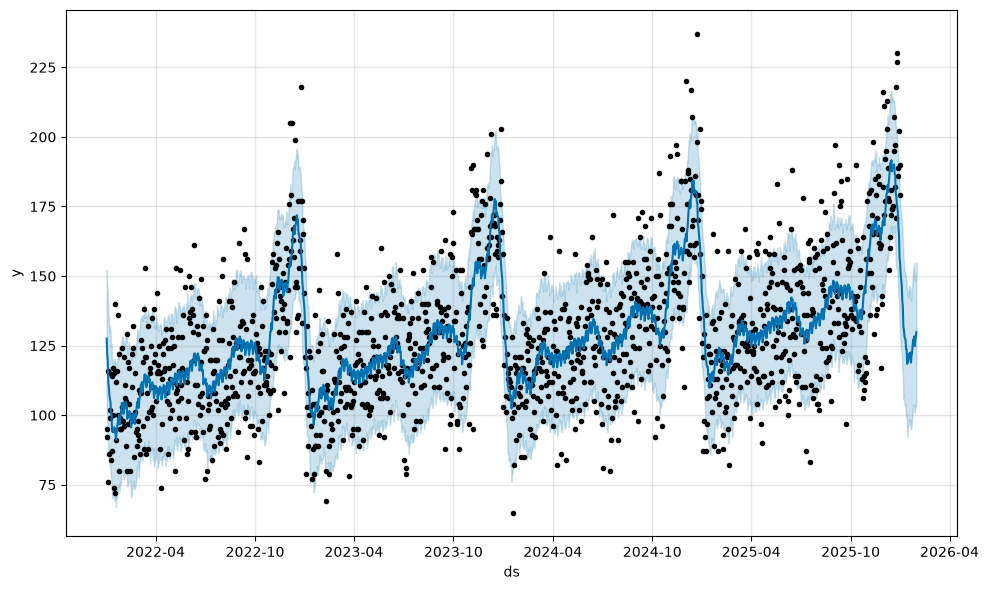

In [20]:
fig = prophet_model.plot(forecast_prophet)

# Model 5: ARIMA Forecasting

In [21]:
from statsmodels.tsa.arima.model import ARIMA

print("ARIMA Imported Successfully")

ARIMA Imported Successfully


# Prepare Time Series Dataset

In [22]:
ts_data = (
    forecast
    .groupby("date")["quantity"]
    .sum()
)

ts_data.head()

date
2022-01-01     92
2022-01-02     95
2022-01-03    116
2022-01-04     76
2022-01-05     86
Name: quantity, dtype: int64

# Train ARIMA Model

In [23]:
arima_model = ARIMA(
    ts_data,
    order=(5,1,0)
)

arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(30)

arima_forecast.head()

C:\Users\HITESH\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HITESH\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HITESH\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2026-01-01    192.920815
2026-01-02    188.655918
2026-01-03    190.197090
2026-01-04    190.534042
2026-01-05    188.702860
Freq: D, Name: predicted_mean, dtype: float64

# ARIMA Forecast Visualization

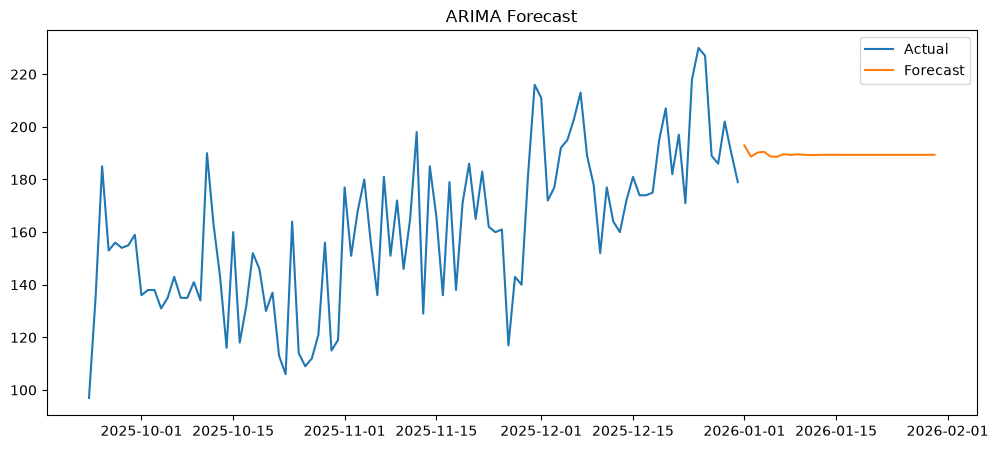

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ts_data.tail(100), label="Actual")

plt.plot(arima_forecast, label="Forecast")

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

# Model Performance Evaluation

The performance of all forecasting models is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score (For Machine Learning Models)

The best-performing model is selected based on the lowest RMSE and highest R² Score.

In [25]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return {

        "Model": model_name,

        "MAE": round(mae,2),

        "RMSE": round(rmse,2),

        "R2 Score": round(r2,4)

    }

# Compare Machine Learning Models

In [26]:
results = []

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.81,1.01,0.1340
1,XGBoost,0.79,0.99,0.1578
2,LightGBM,0.79,0.99,0.1705


# Sort Models by Performance

In [27]:
results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,MAE,RMSE,R2 Score
0,XGBoost,0.79,0.99,0.1578
1,LightGBM,0.79,0.99,0.1705
2,Random Forest,0.81,1.01,0.1340


# Select Best Forecasting Model

In [28]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Forecasting Model")

print(best_model_name)

Best Forecasting Model
XGBoost


# Save Best Forecasting Model

In [29]:
if best_model_name == "Random Forest":

    best_model = rf_model

elif best_model_name == "XGBoost":

    best_model = xgb_model

else:

    best_model = lgbm_model

In [31]:
joblib.dump(

    best_model,

    "../models/best_forecasting_model.pkl"

)

print("Best Forecasting Model Saved Successfully")

Best Forecasting Model Saved Successfully


# Forecasting Summary

### Completed Tasks

- Loaded the Forecast Dataset
- Validated the Dataset
- Selected Forecasting Features
- Performed Time-Based Train-Test Split
- Trained Random Forest Model
- Trained XGBoost Model
- Trained LightGBM Model
- Built Prophet Forecast
- Built ARIMA Forecast
- Compared Machine Learning Models
- Selected the Best Forecasting Model
- Saved the Best Forecasting Model

The saved forecasting model will be used in the next phase for inventory risk prediction and dashboard development.

In [ ]:
prediction_df = X_test.copy()

prediction_df["Actual"] = y_test.values

prediction_df["Predicted"] = xgb_pred

prediction_df.to_csv(
    "../data/processed/predictions.csv",
    index=False
)

results_df.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Predictions and Model Comparison Saved Successfully")

Predictions and Model Comparison Saved Successfully


In [32]:
import pandas as pd

# Load optimized merged dataset
merged = pd.read_csv("../data/processed/merged_dataset.csv")

print("Original Shape:", merged.shape)

# Take maximum 100000 rows
forecast_small = merged.sample(
    n=min(100000, len(merged)),
    random_state=42
)

print("Forecast Shape:", forecast_small.shape)

forecast_small.to_csv(
    "../data/processed/forecast_dataset.csv",
    index=False
)

print("New Forecast Dataset Saved Successfully")

Original Shape: (100000, 36)
Forecast Shape: (100000, 36)
New Forecast Dataset Saved Successfully
